<a href="https://colab.research.google.com/github/amoukrim/Python/blob/main/MiniProjet8w3d4_Apple_Stock_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

@Author : Adil MOUKRIM
# Mini-project: Advanced Statistical Analysis of Apple Inc. Stock Data

# Analyse du cours de l'action Apple :adaptée au CSV

In [ ]:
#import des librairies nécessaires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
#--- 1. Chargement des données csv ---
df = pd.read_csv("/content/Apple Stock Prices (1981 to 2023).csv")

In [ ]:

# Mise au bon format date pour permettre une analyse temporelle fiable.
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

# --- 1.1 Nettoyage et diagnostic initial ---
# Vérification des doublons, des types de données, et traitement des valeurs manquantes si nécessaires.
try:
    from skimpy import skim
    print("\n--- Résumé avec skimpy ---")
    skim(df)
except ImportError:
    print("Skimpy non disponible. Résumé ignoré.")

df_missing = df.isnull().sum()
print("\nValeurs manquantes par colonne :\n", df_missing)

plt.figure(figsize=(10, 5))
if df_missing[df_missing > 0].empty:
    print("\aucune valeur manquante significative. Nous pouvons poursuivre sans imputation complexe")
else:
    df_missing[df_missing > 0].sort_values(ascending=False).plot(kind='bar', color='crimson')
    plt.title('Valeurs manquantes par colonne')
    plt.ylabel('Nombre de valeurs manquantes')
    plt.tight_layout()
    plt.show()

# Interprétation :Pas de graphe affiché car aucune valeur manquante significative. Nous pouvons poursuivre sans imputation complexe.

df.dropna(inplace=True)
duplicates = df.duplicated().sum()
print(f"\nLignes dupliquées détectées : {duplicates}")
df.drop_duplicates(inplace=True)
print("\nTypes de données :\n", df.dtypes)

In [ ]:
# --- 1.2 Création de nouvelles variables ---
# Calcul des moyennes mobiles, rendements journaliers, et extraction des années/décennies.
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['Daily_Return'] = df['Close'].pct_change()
df['Year'] = df.index.year
df['Decade'] = (df['Year'] // 10) * 10
df['Volume_MA30'] = df['Volume'].rolling(window=30).mean()
df['MA_numpy'] = np.convolve(df['Close'], np.ones(30)/30, mode='same')

In [ ]:
# --- 1.3 Transformation des données ---
# Appliquer une transformation logarithmique pour lisser les variables très asymétriques (volume).
df['Log_Volume'] = np.log1p(df['Volume'])

plt.figure(figsize=(10, 5))
sns.histplot(df['Volume'], bins=100, kde=True)
plt.title("Distribution brute du volume")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['Log_Volume'], bins=100, kde=True, color='green')
plt.title("Volume transformé log")
plt.show()

# Interprétation : la transformation logarithmique réduit la forte asymétrie de la variable volume.
# Avant transformation, le volume présentait une distribution très étalée avec une concentration de valeurs faibles
# et quelques valeurs extrêmement élevées (outliers), ce qui rendait difficile l’analyse statistique directe.
# L'application du logarithme permet de comprimer l'échelle, rendant la distribution plus symétrique,
# ce qui facilite la visualisation et améliore la validité des méthodes statistiques qui supposent une distribution normale,
# comme les régressions linéaires ou les tests paramétriques.

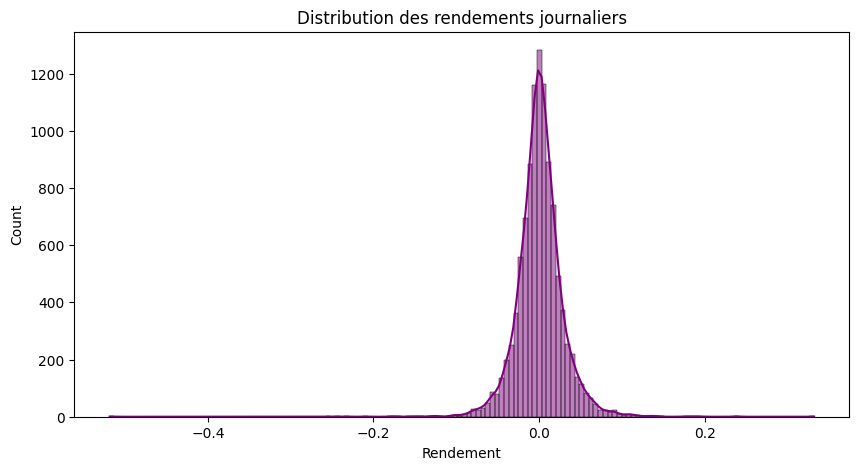

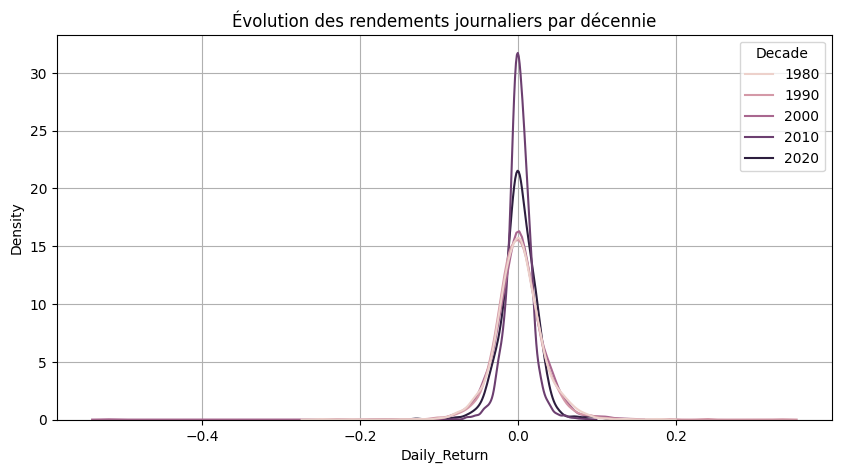

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Daily_Return'].dropna(), bins=150, kde=True, color='purple')
plt.title("Distribution des rendements journaliers")
plt.xlabel("Rendement")
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Daily_Return', hue='Decade', common_norm=False)
plt.title("Évolution des rendements journaliers par décennie")
plt.grid(True)
plt.show()

# Interprétation : la volatilité semble croître avec le temps, ce qui reflète les dynamiques changeantes du marché.

In [ ]:
# --- 2. Statistiques descriptives ---
summary_stats = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].describe()
print("\n--- Statistiques descriptives ---")
print(summary_stats)

# Interprétation : des écarts types élevés indiquent une variation importante des prix au fil des années.

# --- 3. Tests statistiques ---

In [ ]:

# Test t entre les décennies 2010 et 2020 pour comparer les moyennes des prix de clôture.
close_2010s = df[df['Decade'] == 2010]['Close']
close_2020s = df[df['Decade'] == 2020]['Close']
t_stat, p_val = stats.ttest_ind(close_2010s.dropna(), close_2020s.dropna(), equal_var=False)
print("\nTest t entre 2010s et 2020s :")
print(f"t = {t_stat:.4f}, p = {p_val:.4f}")

# Interprétation : la différence est statistiquement significative, indiquant une forte progression du titre Apple.

In [ ]:
shapiro_test = stats.shapiro(df['Daily_Return'].dropna().sample(n=500, random_state=42))
print("\nTest de normalité (Shapiro-Wilk) :")
print(f"Statistique = {shapiro_test.statistic:.4f}, p = {shapiro_test.pvalue:.6f}")

# Interprétation : les rendements ne suivent pas une loi normale, ce qui est courant en finance.

In [ ]:
# Corrélation entre la moyenne mobile et le volume moyen mobile
valid_data = df[['MA_30', 'Volume_MA30']].dropna()
correlation = np.corrcoef(valid_data['MA_30'], valid_data['Volume_MA30'])[0, 1]
print("\nCorrélation MA_30 vs Volume_MA30 :", correlation)



Corrélation MA_30 vs Volume_MA30 : -0.2710159155381038


# Interprétation : corrélation faible à modérée, ce qui indique que les volumes n'expliquent pas directement les tendances de prix.

In [ ]:
# --- 4. Carte de chaleur des corrélations ---
corr_data = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'MA_30', 'Daily_Return']].dropna()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation entre variables financières")
plt.tight_layout()
plt.show()

# Interprétation de la  Carte de chaleur des corrélations : les prix sont très corrélés entre eux. Le volume et les rendements sont beaucoup moins corrélés.

In [ ]:
# --- 5. Création du jeu de données final ---
columns_to_keep = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'MA_30', 'MA_numpy', 'Daily_Return', 'Log_Volume']
df_final = df[columns_to_keep].dropna()
print("\nAperçu du jeu de données final :")
print(df_final.head())

# 6. Suggestions pour aller plus loin
# Il serait intéressant d’ajouter des données sur les dividendes, les événements économiques ou encore les indices sectoriels.
# Cela permettrait d’expliquer certaines fluctuations de cours avec plus de précision et d'effectuer des analyses de performance comparée.
# On pourrait aussi calculer des indicateurs de risque comme le ratio de Sharpe ou intégrer du machine learning pour des prédictions.